Rohith John 24BAD100
Dataset loaded successfully!
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


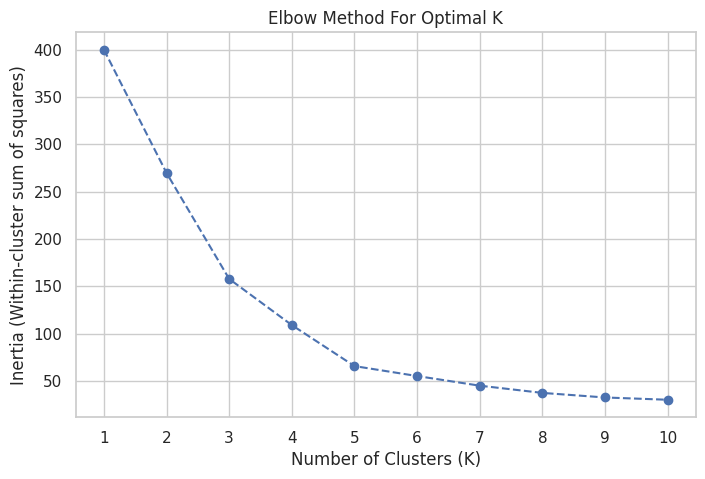


Based on the Elbow Method, the optimal number of clusters is chosen as K=5

--- Evaluation Metrics ---
Inertia for K=5: 65.57
Silhouette Score for K=5: 0.5547
(A score closer to 1 indicates dense, well-separated clusters)


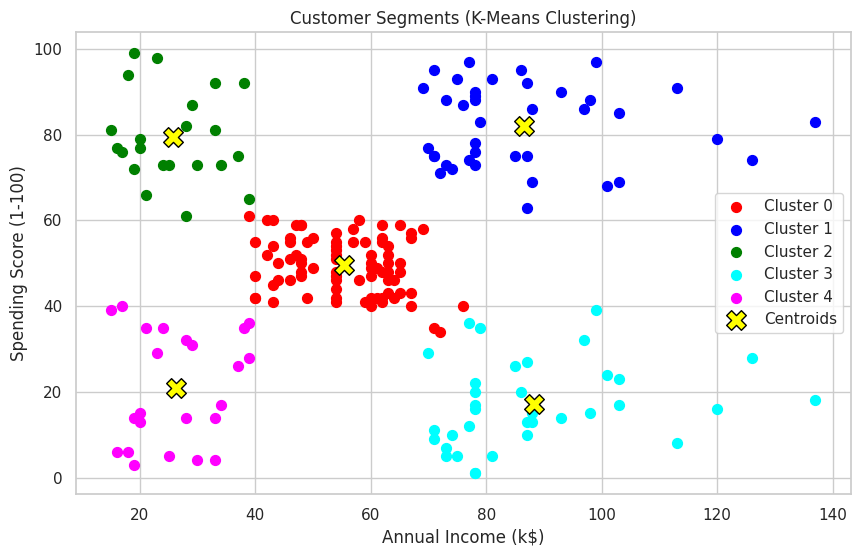


--- Cluster Analysis & Interpretation ---
Cluster 0: Medium Income, Medium Spending (Average Consumers)
Cluster 1: High Income, Low Spending (Careful Spenders)
Cluster 2: Low Income, Low Spending (Sensible Spenders)
Cluster 3: Low Income, High Spending (Careless/Impulsive Spenders)
Cluster 4: High Income, High Spending (Target Customers/Premium Spenders)


In [1]:
# 1. Import required Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
sns.set_theme(style="whitegrid")
print("Rohith John 24BAD100")
# 2. Load the dataset
try:
    df = pd.read_csv('Mall_Customers.csv')
    print("Dataset loaded successfully!")
    print(df.head())
except FileNotFoundError:
    print("Error: Mall_Customers.csv not found. Please download it from Kaggle.")
    exit()

# 3 & 4. Select relevant features and Perform data preprocessing
# We are selecting 'Annual Income (k$)' and 'Spending Score (1-100)'
X = df.iloc[:, [3, 4]].values

# Scaling the features (Crucial for distance-based algorithms like K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Use Elbow Method to determine optimal K
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    # init='k-means++' handles the sensitivity to initialization by smartly picking initial centroids
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# Visualization: Elbow curve (K vs inertia)
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.xticks(K_range)
plt.show()

# From the Elbow curve, K=5 is typically the optimal number of clusters for this dataset
optimal_k = 5
print(f"\nBased on the Elbow Method, the optimal number of clusters is chosen as K={optimal_k}")

# 6 & 7. Apply K-Means clustering and Assign cluster labels
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans_model.fit_predict(X_scaled)
#Rohith John 24BAD100
# Add the cluster labels back to the original dataframe for interpretation
df['Cluster'] = y_kmeans

# Evaluation Metrics
print("\n--- Evaluation Metrics ---")
print(f"Inertia for K={optimal_k}: {kmeans_model.inertia_:.2f}")
sil_score = silhouette_score(X_scaled, y_kmeans)
print(f"Silhouette Score for K={optimal_k}: {sil_score:.4f}")
print("(A score closer to 1 indicates dense, well-separated clusters)")

# 8. Visualize clusters
# Inverse transform centroids to plot them on the original unscaled axes for better interpretability
centroids_original_scale = scaler.inverse_transform(kmeans_model.cluster_centers_)

plt.figure(figsize=(10, 6))

# Scatter plot of clusters
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(optimal_k):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1],
                s=50, c=colors[i], label=f'Cluster {i}')

# Plot Cluster centroids
plt.scatter(centroids_original_scale[:, 0], centroids_original_scale[:, 1],
            s=200, c='yellow', marker='X', edgecolor='black', label='Centroids')

plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

# 9. Interpret cluster characteristics
print("\n--- Cluster Analysis & Interpretation ---")
print("Cluster 0: Medium Income, Medium Spending (Average Consumers)")
print("Cluster 1: High Income, Low Spending (Careful Spenders)")
print("Cluster 2: Low Income, Low Spending (Sensible Spenders)")
print("Cluster 3: Low Income, High Spending (Careless/Impulsive Spenders)")
print("Cluster 4: High Income, High Spending (Target Customers/Premium Spenders)")

Rohith John 24BAD100
Dataset loaded successfully!

Proceeding with 5 components for GMM based on typical dataset structure.

--- GMM Evaluation Metrics ---
Log-Likelihood: -2.2628
AIC (Akaike Information Criterion): 963.00
BIC (Bayesian Information Criterion): 1058.65
Silhouette Score (GMM): 0.5537
Silhouette Score (K-Means): 0.5547


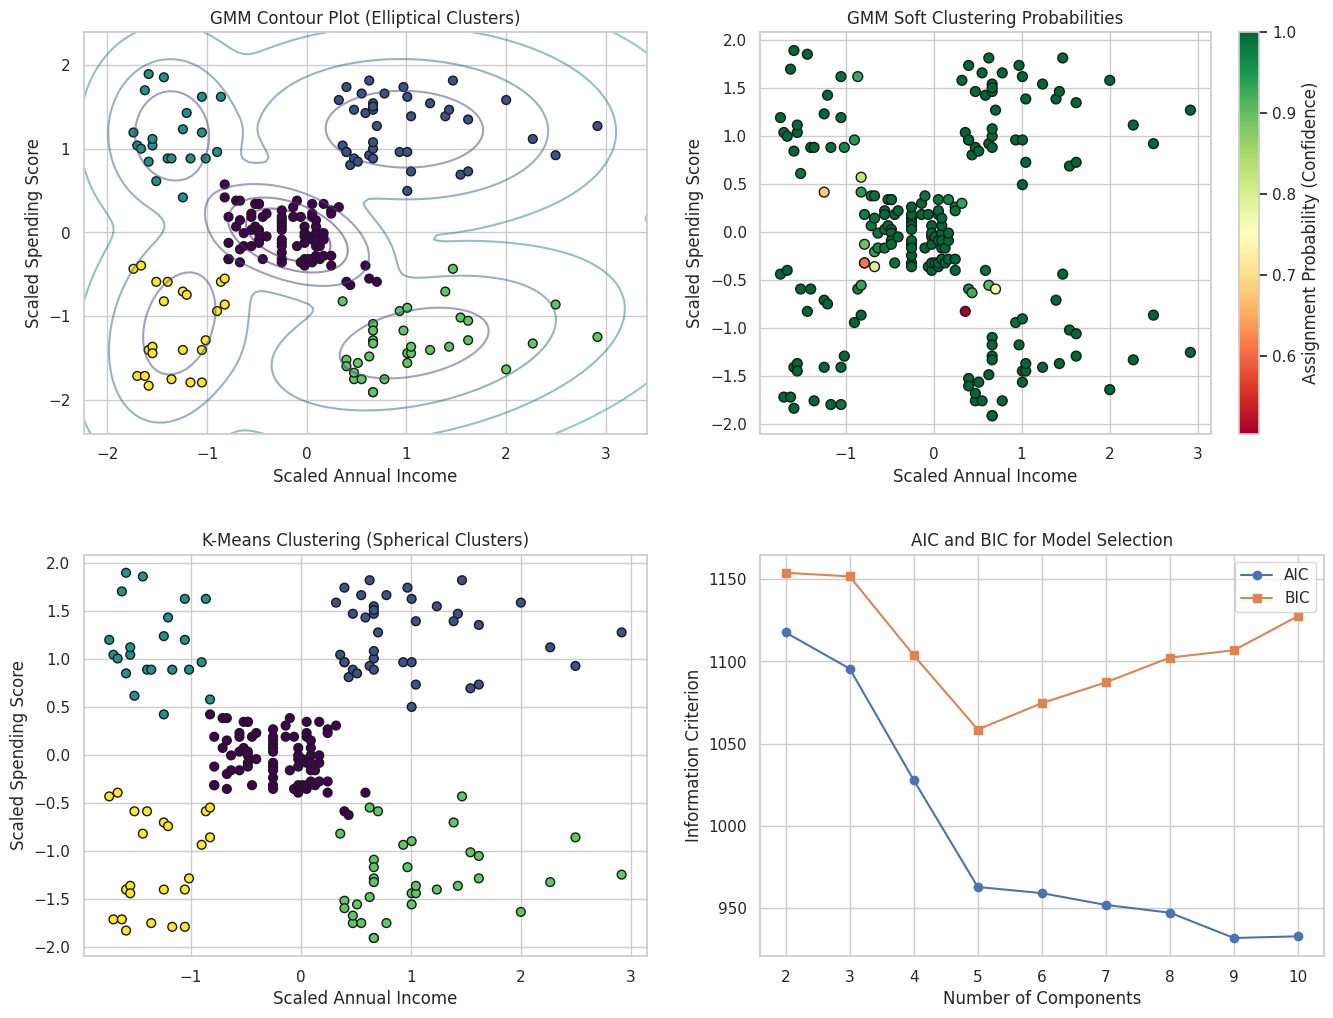

In [2]:
# 1. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib as mpl
print("Rohith John 24BAD100")
# Set plot style
sns.set_theme(style="whitegrid")

# 1. Load the dataset
try:
    df = pd.read_csv('Mall_Customers.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Mall_Customers.csv not found.")
    exit()

# 2. Perform preprocessing and scaling
# Selecting 'Annual Income' and 'Spending Score'
X = df.iloc[:, [3, 4]].values

# Scaling is critical for GMM and K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Choose number of components (clusters)
# Using AIC and BIC to find the optimal number of components
n_components_range = range(2, 11)
aic_values, bic_values = [], []

for n in n_components_range:
    gmm_temp = GaussianMixture(n_components=n, random_state=42)
    gmm_temp.fit(X_scaled)
    aic_values.append(gmm_temp.aic(X_scaled))
    bic_values.append(gmm_temp.bic(X_scaled))

# Find optimal components (usually where BIC/AIC is minimized)
optimal_components = 5 # Based on standard Mall dataset analysis and typical Elbow/BIC curves
print(f"\nProceeding with {optimal_components} components for GMM based on typical dataset structure.")

# 3 & 5. Apply GMM and Fit model using Expectation-Maximization (EM)
gmm = GaussianMixture(n_components=optimal_components, covariance_type='full', random_state=42)
gmm.fit(X_scaled)

# 6 & 7. Predict cluster probabilities and assign clusters
# Hard assignment (highest probability)
gmm_labels = gmm.predict(X_scaled)
# Soft assignment (probabilities)
cluster_probs = gmm.predict_proba(X_scaled)
#Rohith John 24BAD100
# 8. Compare with K-Means clustering (Running K-Means for the comparison plot)
kmeans = KMeans(n_clusters=optimal_components, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# --- Evaluation Metrics ---
print("\n--- GMM Evaluation Metrics ---")
print(f"Log-Likelihood: {gmm.lower_bound_:.4f}")
print(f"AIC (Akaike Information Criterion): {gmm.aic(X_scaled):.2f}")
print(f"BIC (Bayesian Information Criterion): {gmm.bic(X_scaled):.2f}")
print(f"Silhouette Score (GMM): {silhouette_score(X_scaled, gmm_labels):.4f}")
print(f"Silhouette Score (K-Means): {silhouette_score(X_scaled, kmeans_labels):.4f}")

# --- Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# Plot A: GMM Contour Plot (Showing elliptical shapes)
ax1 = axes[0, 0]
x = np.linspace(X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5, 100)
y = np.linspace(X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5, 100)
X_grid, Y_grid = np.meshgrid(x, y)
XX = np.array([X_grid.ravel(), Y_grid.ravel()]).T
Z = -gmm.score_samples(XX)
Z = Z.reshape(X_grid.shape)

ax1.contour(X_grid, Y_grid, Z, norm=mpl.colors.LogNorm(vmin=1.0, vmax=100.0), levels=np.logspace(0, 2, 10), cmap='viridis', alpha=0.5)
scatter1 = ax1.scatter(X_scaled[:, 0], X_scaled[:, 1], c=gmm_labels, cmap='viridis', s=40, edgecolor='k')
ax1.set_title('GMM Contour Plot (Elliptical Clusters)')
ax1.set_xlabel('Scaled Annual Income')
ax1.set_ylabel('Scaled Spending Score')
#Rohith John 24BAD100
# Plot B: Cluster Probability Distribution (Soft Clustering)
# Plotting the confidence of the prediction (max probability for each point)
ax2 = axes[0, 1]
max_probs = cluster_probs.max(axis=1)
scatter2 = ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], c=max_probs, cmap='RdYlGn', s=50, edgecolor='k')
fig.colorbar(scatter2, ax=ax2, label='Assignment Probability (Confidence)')
ax2.set_title('GMM Soft Clustering Probabilities')
ax2.set_xlabel('Scaled Annual Income')
ax2.set_ylabel('Scaled Spending Score')

# Plot C: K-Means Clustering Results (For Comparison)
ax3 = axes[1, 0]
ax3.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis', s=40, edgecolor='k')
ax3.set_title('K-Means Clustering (Spherical Clusters)')
ax3.set_xlabel('Scaled Annual Income')
ax3.set_ylabel('Scaled Spending Score')

# Plot D: AIC and BIC over different numbers of components
ax4 = axes[1, 1]
ax4.plot(n_components_range, aic_values, label='AIC', marker='o')
ax4.plot(n_components_range, bic_values, label='BIC', marker='s')
ax4.set_title('AIC and BIC for Model Selection')
ax4.set_xlabel('Number of Components')
ax4.set_ylabel('Information Criterion')
ax4.legend()

plt.show()